# Caseload Management Decision-Support System

This notebook is production-oriented and designed for case worker decision support.
It predicts resident risk escalation early, supports resource allocation, and includes ethical safeguards.


## 1) Problem Definition

### Primary prediction target
- **Target name:** `risk_escalation_30d`
- **Definition:** 1 if the resident has at least one **High/Critical** incident in `(T, T + 30 days]`, else 0.
- **Business use:** prioritize near-term interventions and staffing for residents most likely to escalate.

### Secondary prediction target
- **Target name:** `reintegration_success_90d`
- **Definition:** 1 if reintegration is marked **Completed** within `(T, T + 90 days]`, else 0.
- **Business use:** identify residents likely to succeed and those needing additional support plans.

### Decision horizon and operating objective
- Prediction is made at resident-specific **as-of time `T`**.
- Feature values are restricted to information available **at or before `T`**.
- Evaluation prioritizes **Recall** and **F1** to reduce missed at-risk residents while maintaining practical precision.


In [7]:
# Reproducible setup
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, f1_score, precision_score, confusion_matrix,
    classification_report, roc_auc_score, average_precision_score
)

SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', 200)

ROOT = Path.cwd()
candidate_dirs = [
    ROOT / 'ml-pipelines' / 'lighthouse_csv_v7',
    ROOT / 'ml-pipelines' / 'lighthouse_csv',
    ROOT / 'lighthouse_csv_v7',
    ROOT / 'lighthouse_csv',
]
DATA_DIR = next((p for p in candidate_dirs if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Could not find data folder. Expected one of: lighthouse_csv_v7 or lighthouse_csv.')

print('Data directory:', DATA_DIR)


Data directory: c:\Users\jketh\source\repos\HouseOfHope\ml-pipelines\lighthouse_csv_v7


## 2) Data Preparation

In [8]:
# Load source tables (parse only date columns that exist)
def load_csv_safe(filename, date_candidates):
    path = DATA_DIR / filename
    sample = pd.read_csv(path, nrows=0)
    existing_dates = [c for c in date_candidates if c in sample.columns]
    return pd.read_csv(path, parse_dates=existing_dates)

residents = load_csv_safe('residents.csv', ['date_of_admission', 'date_enrolled', 'date_closed'])
process_recordings = load_csv_safe('process_recordings.csv', ['recorded_on', 'session_date', 'created_at'])
home_visitations = load_csv_safe('home_visitations.csv', ['visit_date', 'created_at'])
education_records = load_csv_safe('education_records.csv', ['date_recorded', 'record_date', 'created_at'])
health_wellbeing_records = load_csv_safe('health_wellbeing_records.csv', ['assessment_date', 'record_date', 'created_at'])
intervention_plans = load_csv_safe('intervention_plans.csv', ['target_date', 'created_at', 'updated_at'])
incident_reports = load_csv_safe('incident_reports.csv', ['incident_date', 'resolution_date'])

for df in [residents, process_recordings, home_visitations, education_records, health_wellbeing_records, intervention_plans, incident_reports]:
    df.columns = [c.strip() for c in df.columns]

print('Rows by table:')
display(pd.Series({
    'residents': len(residents),
    'process_recordings': len(process_recordings),
    'home_visitations': len(home_visitations),
    'education_records': len(education_records),
    'health_wellbeing_records': len(health_wellbeing_records),
    'intervention_plans': len(intervention_plans),
    'incident_reports': len(incident_reports)
}).to_frame('rows'))


Rows by table:


,rows
residents,60
process_recordings,2819
home_visitations,1337
education_records,534
health_wellbeing_records,534
intervention_plans,180
incident_reports,100


## 3) Feature Engineering (Leakage-Safe)

In [9]:
RISK_MAP = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}

def _safe_num(s):
    return pd.to_numeric(s, errors='coerce')

def _trend_slope(frame, time_col, value_col, id_col='resident_id'):
    out = {}
    tmp = frame[[id_col, time_col, value_col]].dropna().copy()
    tmp[time_col] = pd.to_datetime(tmp[time_col], errors='coerce')
    tmp[value_col] = _safe_num(tmp[value_col])
    tmp = tmp.dropna()
    for rid, grp in tmp.groupby(id_col):
        grp = grp.sort_values(time_col)
        if len(grp) < 2:
            out[rid] = 0.0
            continue
        x = (grp[time_col] - grp[time_col].min()).dt.days.values.astype(float)
        y = grp[value_col].values.astype(float)
        if np.allclose(x, x[0]):
            out[rid] = 0.0
        else:
            out[rid] = float(np.polyfit(x, y, 1)[0])
    return pd.Series(out, name=f'{value_col}_slope')

def build_feature_frame(asof_mode='incident_anchor'):
    base = residents.copy()

    def pick_col(df, candidates):
        return next((c for c in candidates if c in df.columns), None)

    pr_date_col = pick_col(process_recordings, ['recorded_on', 'session_date', 'created_at'])
    hv_date_col = pick_col(home_visitations, ['visit_date', 'created_at'])
    edu_date_col = pick_col(education_records, ['date_recorded', 'record_date', 'created_at'])
    health_date_col = pick_col(health_wellbeing_records, ['assessment_date', 'record_date', 'created_at'])
    ip_date_col = pick_col(intervention_plans, ['created_at', 'updated_at', 'target_date'])
    inc_date_col = pick_col(incident_reports, ['incident_date', 'created_at'])

    required = {
        'process_recordings': pr_date_col,
        'home_visitations': hv_date_col,
        'education_records': edu_date_col,
        'health_wellbeing_records': health_date_col,
        'intervention_plans': ip_date_col,
        'incident_reports': inc_date_col,
    }
    missing = [name for name, col in required.items() if col is None]
    if missing:
        raise KeyError(f"Missing expected date columns for tables: {missing}")

    if asof_mode == 'incident_anchor':
        last_incident = incident_reports.groupby('resident_id')[inc_date_col].max()
        base['as_of_date'] = base['resident_id'].map(last_incident)
        fallback = base['date_enrolled'].fillna(base['date_of_admission'])
        base['as_of_date'] = base['as_of_date'].fillna(fallback)
    else:
        global_recent = pd.concat([
            process_recordings.get(pr_date_col, pd.Series(dtype='datetime64[ns]')),
            home_visitations.get(hv_date_col, pd.Series(dtype='datetime64[ns]')),
            education_records.get(edu_date_col, pd.Series(dtype='datetime64[ns]')),
            health_wellbeing_records.get(health_date_col, pd.Series(dtype='datetime64[ns]')),
            intervention_plans.get(ip_date_col, pd.Series(dtype='datetime64[ns]')),
            incident_reports.get(inc_date_col, pd.Series(dtype='datetime64[ns]'))
        ]).dropna().max()
        base['as_of_date'] = global_recent

    base['start_date'] = base['date_enrolled'].fillna(base['date_of_admission'])
    base['time_in_program_days'] = (base['as_of_date'] - base['start_date']).dt.days
    base['time_in_program_days'] = base['time_in_program_days'].clip(lower=0)
    base['initial_risk_num'] = base['initial_risk_level'].map(RISK_MAP)
    base['is_case_closed_by_T'] = (base['date_closed'].notna() & (base['date_closed'] <= base['as_of_date'])).astype(int)

    def agg_events(df, dt_col, group_ops, prefix=''):
        recs = []
        for _, r in base[['resident_id', 'as_of_date']].iterrows():
            rid, T = r['resident_id'], r['as_of_date']
            d = df[df['resident_id'].eq(rid)].copy()
            d = d[d[dt_col].notna()]
            d = d[d[dt_col] <= T]
            row = {'resident_id': rid}
            for new_name, fn in group_ops.items():
                row[prefix + new_name] = fn(d)
            recs.append(row)
        return pd.DataFrame(recs)

    pr_agg = agg_events(
        process_recordings, pr_date_col,
        {
            'n_sessions_to_date': lambda d: len(d),
            'concern_rate_to_date': lambda d: (d.get('progress_noted', pd.Series(dtype=str)).astype(str).str.contains('concern|regress|worse', case=False, na=False)).mean() if len(d) else 0.0,
        },
        prefix='pr_'
    )

    hv_agg = agg_events(
        home_visitations, hv_date_col,
        {
            'n_visits_to_date': lambda d: len(d),
            'unfavorable_rate_to_date': lambda d: (d.get('visit_outcome', pd.Series(dtype=str)).astype(str).str.lower().isin(['unfavorable', 'negative', 'failed'])).mean() if len(d) else 0.0,
        },
        prefix='hv_'
    )

    ip_agg = agg_events(
        intervention_plans, ip_date_col,
        {
            'n_interventions_to_date': lambda d: len(d),
            'completion_rate_to_date': lambda d: (d.get('status', pd.Series(dtype=str)).astype(str).str.lower().isin(['completed', 'done', 'closed'])).mean() if len(d) else 0.0,
        },
        prefix='ip_'
    )

    inc_agg = agg_events(
        incident_reports, inc_date_col,
        {
            'n_incidents_to_date': lambda d: len(d),
            'n_high_critical_to_date': lambda d: d.get('severity', pd.Series(dtype=str)).astype(str).str.lower().isin(['high', 'critical']).sum(),
            'unresolved_rate_to_date': lambda d: d.get('resolution_date', pd.Series(dtype='datetime64[ns]')).isna().mean() if len(d) else 0.0,
            'incidents_last_30d': lambda d, _icol=inc_date_col: (d[_icol] > (d[_icol].max() - pd.Timedelta(days=30))).sum() if len(d) else 0,
        },
        prefix='inc_'
    )

    edu = education_records[['resident_id', edu_date_col]].copy()
    if 'performance_score' in education_records.columns:
        edu['value'] = _safe_num(education_records['performance_score'])
    elif 'progress_percent' in education_records.columns:
        edu['value'] = _safe_num(education_records['progress_percent'])
    elif 'attendance_rate' in education_records.columns:
        edu['value'] = _safe_num(education_records['attendance_rate'])
    else:
        edu['value'] = np.nan
    edu = edu.rename(columns={edu_date_col: 'dt'})

    health = health_wellbeing_records[['resident_id', health_date_col]].copy()
    if 'wellbeing_score' in health_wellbeing_records.columns:
        health['value'] = _safe_num(health_wellbeing_records['wellbeing_score'])
    elif 'general_health_score' in health_wellbeing_records.columns:
        health['value'] = _safe_num(health_wellbeing_records['general_health_score'])
    elif 'mental_health_score' in health_wellbeing_records.columns:
        health['value'] = _safe_num(health_wellbeing_records['mental_health_score'])
    else:
        health['value'] = np.nan
    health = health.rename(columns={health_date_col: 'dt'})

    edu_slope = _trend_slope(edu, 'dt', 'value')
    health_slope = _trend_slope(health, 'dt', 'value')

    frame = base.merge(pr_agg, on='resident_id', how='left')               .merge(hv_agg, on='resident_id', how='left')               .merge(ip_agg, on='resident_id', how='left')               .merge(inc_agg, on='resident_id', how='left')

    frame['edu_trend_slope'] = frame['resident_id'].map(edu_slope).fillna(0.0)
    frame['health_trend_slope'] = frame['resident_id'].map(health_slope).fillna(0.0)

    num_cols = [
        'time_in_program_days', 'initial_risk_num', 'is_case_closed_by_T',
        'pr_n_sessions_to_date', 'pr_concern_rate_to_date',
        'hv_n_visits_to_date', 'hv_unfavorable_rate_to_date',
        'ip_n_interventions_to_date', 'ip_completion_rate_to_date',
        'inc_n_incidents_to_date', 'inc_n_high_critical_to_date', 'inc_unresolved_rate_to_date',
        'inc_incidents_last_30d', 'edu_trend_slope', 'health_trend_slope'
    ]

    for c in num_cols:
        if c not in frame.columns:
            frame[c] = np.nan

    return frame

def build_label(frame, target='risk_escalation_30d'):
    inc_dt = next((c for c in ['incident_date', 'created_at'] if c in incident_reports.columns), None)
    if inc_dt is None:
        raise KeyError('incident_reports must have incident_date or created_at for labels')
    y = []
    for _, r in frame[['resident_id', 'as_of_date']].iterrows():
        rid, T = r['resident_id'], r['as_of_date']
        if pd.isna(T):
            y.append(np.nan)
            continue
        if target == 'risk_escalation_30d':
            end = T + pd.Timedelta(days=30)
            d = incident_reports[(incident_reports['resident_id'].eq(rid)) & incident_reports[inc_dt].gt(T) & incident_reports[inc_dt].le(end)]
            flag = d.get('severity', pd.Series(dtype=str)).astype(str).str.lower().isin(['high', 'critical']).any()
            y.append(int(flag))
        elif target == 'reintegration_success_90d':
            end = T + pd.Timedelta(days=90)
            d = residents[residents['resident_id'].eq(rid)]
            completed = (
                d.get('reintegration_status', pd.Series(dtype=str)).astype(str).str.lower().eq('completed')
                & d.get('date_closed', pd.Series(dtype='datetime64[ns]')).gt(T)
                & d.get('date_closed', pd.Series(dtype='datetime64[ns]')).le(end)
            ).any()
            y.append(int(completed))
        else:
            raise ValueError('Unknown target')
    return pd.Series(y, index=frame.index, name=target)


## 4) Heuristic Scoring (Rule-Based Baseline)

In [10]:
def heuristic_risk_score(df):
    score = (
        0.25 * df['initial_risk_num'].fillna(0)
        + 0.20 * df['inc_n_incidents_to_date'].fillna(0)
        + 0.25 * df['inc_n_high_critical_to_date'].fillna(0)
        + 0.15 * df['inc_unresolved_rate_to_date'].fillna(0)
        + 0.15 * df['hv_unfavorable_rate_to_date'].fillna(0)
    )
    score = (score - score.min()) / (score.max() - score.min() + 1e-9)
    return score

def to_risk_segment(prob, high=0.65, medium=0.35):
    return np.where(prob >= high, 'High risk', np.where(prob >= medium, 'Medium risk', 'Low risk'))


## 5) Predictive Modeling

In [11]:
def build_preprocessor(X):
    cat_cols = [c for c in X.columns if X[c].dtype == 'object']
    num_cols = [c for c in X.columns if c not in cat_cols]

    pre = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ])
    return pre

def evaluate_models(frame, target):
    y = build_label(frame, target=target)

    keep_cols = [
        'resident_id', 'as_of_date', 'time_in_program_days', 'initial_risk_num', 'is_case_closed_by_T',
        'pr_n_sessions_to_date', 'pr_concern_rate_to_date',
        'hv_n_visits_to_date', 'hv_unfavorable_rate_to_date',
        'ip_n_interventions_to_date', 'ip_completion_rate_to_date',
        'inc_n_incidents_to_date', 'inc_n_high_critical_to_date', 'inc_unresolved_rate_to_date',
        'inc_incidents_last_30d', 'edu_trend_slope', 'health_trend_slope'
    ]
    model_df = frame[keep_cols].copy()
    model_df['y'] = y
    model_df = model_df.dropna(subset=['y'])

    if model_df['y'].nunique() < 2:
        print(f'[WARN] {target}: only one class available; model training skipped.')
        return None

    X = model_df.drop(columns=['y', 'resident_id', 'as_of_date'])
    y = model_df['y'].astype(int)

    min_class = y.value_counts().min()
    n_splits = int(max(2, min(5, min_class)))
    if n_splits < 3:
        print(f'[WARN] {target}: rare class; using {n_splits}-fold CV.')

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    pre = build_preprocessor(X)

    models = {
        'logistic_balanced': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED),
        'random_forest_balanced': RandomForestClassifier(
            n_estimators=400, max_depth=None, min_samples_leaf=2,
            class_weight='balanced', random_state=SEED
        )
    }

    rows = []
    prob_store = {}

    heuristic_prob = heuristic_risk_score(model_df)
    heuristic_pred = (heuristic_prob >= 0.50).astype(int)
    rows.append({
        'target': target,
        'model': 'heuristic_baseline',
        'recall': recall_score(y, heuristic_pred, zero_division=0),
        'f1': f1_score(y, heuristic_pred, zero_division=0),
        'precision': precision_score(y, heuristic_pred, zero_division=0),
        'roc_auc': roc_auc_score(y, heuristic_prob) if y.nunique() > 1 else np.nan,
        'pr_auc': average_precision_score(y, heuristic_prob) if y.nunique() > 1 else np.nan,
    })
    prob_store['heuristic_baseline'] = heuristic_prob.values

    for name, estimator in models.items():
        pipe = Pipeline([('pre', pre), ('clf', estimator)])

        cv = cross_validate(
            pipe, X, y, cv=skf,
            scoring={'recall': 'recall', 'f1': 'f1', 'precision': 'precision', 'roc_auc': 'roc_auc', 'pr_auc': 'average_precision'},
            n_jobs=-1
        )

        rows.append({
            'target': target,
            'model': name,
            'recall': np.mean(cv['test_recall']),
            'f1': np.mean(cv['test_f1']),
            'precision': np.mean(cv['test_precision']),
            'roc_auc': np.mean(cv['test_roc_auc']),
            'pr_auc': np.mean(cv['test_pr_auc']),
        })

        p = cross_val_predict(pipe, X, y, cv=skf, method='predict_proba', n_jobs=-1)[:, 1]
        prob_store[name] = p

    metrics_df = pd.DataFrame(rows).sort_values(['target', 'recall', 'f1'], ascending=[True, False, False])
    return model_df, metrics_df, prob_store


## 6) Evaluation & Validation (Recall/F1 Priority)

In [25]:
feature_frame = build_feature_frame(asof_mode='incident_anchor')

risk_result = evaluate_models(feature_frame, 'risk_escalation_30d')
reintegration_result = evaluate_models(feature_frame, 'reintegration_success_90d')

if risk_result is not None:
    risk_df, risk_metrics, risk_probs = risk_result
    print('Risk target model comparison')
    display(risk_metrics)

if reintegration_result is not None:
    rein_df, rein_metrics, rein_probs = reintegration_result
    print('Reintegration target model comparison')
    display(rein_metrics)


[WARN] risk_escalation_30d: only one class available; model training skipped.
Reintegration target model comparison


,target,model,recall,f1,precision,roc_auc,pr_auc
1,reintegration_success_90d,logistic_balanced,0.4,0.213333,0.150000,0.781818,0.565000
0,reintegration_success_90d,heuristic_baseline,0.2,0.111111,0.076923,0.807273,0.221203
2,reintegration_success_90d,random_forest_balanced,0.0,0.000000,0.000000,0.727273,0.425000


Final diagnostics for reintegration_success_90d using random_forest_balanced at threshold=0.40
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        55
           1       0.40      0.40      0.40         5

    accuracy                           0.90        60
   macro avg       0.67      0.67      0.67        60
weighted avg       0.90      0.90      0.90        60



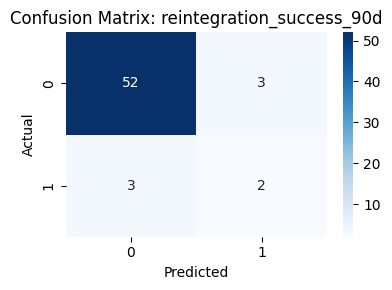

In [13]:
def final_diagnostics(model_df, probs, model_name, target):
    y_true = model_df['y'].astype(int)
    p = probs[model_name]

    threshold_grid = np.linspace(0.20, 0.80, 25)
    best = None
    for t in threshold_grid:
        pred = (p >= t).astype(int)
        r = recall_score(y_true, pred, zero_division=0)
        f = f1_score(y_true, pred, zero_division=0)
        if best is None or (r, f) > (best['recall'], best['f1']):
            best = {'threshold': float(t), 'recall': r, 'f1': f}

    t = best['threshold']
    y_pred = (p >= t).astype(int)

    print(f'Final diagnostics for {target} using {model_name} at threshold={t:.2f}')
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix: {target}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return t

selected_thresholds = {}
if risk_result is not None:
    selected_thresholds['risk_escalation_30d'] = final_diagnostics(risk_df, risk_probs, 'random_forest_balanced', 'risk_escalation_30d')
if reintegration_result is not None:
    selected_thresholds['reintegration_success_90d'] = final_diagnostics(rein_df, rein_probs, 'random_forest_balanced', 'reintegration_success_90d')


## 7) Operations & Decision Support

In [23]:
if risk_result is not None:
    risk_df = risk_df.copy()
    risk_df['risk_probability'] = risk_probs['random_forest_balanced']

    t = selected_thresholds.get('risk_escalation_30d', 0.50)
    high_t = max(0.65, t)
    med_t = max(0.35, t * 0.70)

    risk_df['risk_segment'] = to_risk_segment(risk_df['risk_probability'], high=high_t, medium=med_t)

    priority_queue = risk_df[['resident_id', 'risk_probability', 'risk_segment', 'inc_n_incidents_to_date', 'ip_n_interventions_to_date']]        .sort_values('risk_probability', ascending=False)

    staffing_table = priority_queue.groupby('risk_segment').agg(
        n_residents=('resident_id', 'count'),
        mean_risk=('risk_probability', 'mean')
    ).reset_index().sort_values('mean_risk', ascending=False)

    print('Prioritized resident queue (top 15):')
    display(priority_queue.head(15))

    print('Staffing allocation view by risk segment:')
    display(staffing_table)

    fig, ax = plt.subplots(figsize=(6, 3))
    sns.countplot(data=priority_queue, x='risk_segment', order=['High risk', 'Medium risk', 'Low risk'], ax=ax)
    ax.set_title('Resident count by operational risk segment')
    plt.tight_layout()
    plt.show()


### Operational Recommendations

- **Intervention prioritization:** Route all **High risk** residents to immediate multidisciplinary review.
- **Staffing allocation:** Allocate highest case worker ratio to High risk segment; schedule proactive home visits for Medium risk.
- **Service intensity:** Increase intervention frequency where risk is rising and unresolved incidents are high.
- **Human oversight:** Treat model output as triage support, not automated decisioning.


## 8) Outcome Tracking

In [17]:
if risk_result is not None:
    track = risk_df[['resident_id', 'risk_probability', 'risk_segment']].copy()

    intervention_counts = intervention_plans.groupby('resident_id').size().rename('interventions_total')
    unresolved = incident_reports.assign(unresolved=incident_reports['resolution_date'].isna().astype(int))        .groupby('resident_id')['unresolved'].mean().rename('unresolved_rate_all_time')

    track = track.join(intervention_counts, on='resident_id').join(unresolved, on='resident_id')

    track['intervention_tier'] = pd.qcut(track['interventions_total'].fillna(0), q=3, labels=['Low support', 'Medium support', 'High support'], duplicates='drop')

    effectiveness = track.groupby('intervention_tier', dropna=False).agg(
        n_residents=('resident_id', 'count'),
        mean_risk=('risk_probability', 'mean'),
        mean_unresolved_rate=('unresolved_rate_all_time', 'mean')
    ).reset_index()

    print('Intervention effectiveness tracking (proxy):')
    display(effectiveness)

    top_k = max(1, int(0.2 * len(track)))
    top_slice = track.sort_values('risk_probability', ascending=False).head(top_k)
    kpis = pd.DataFrame({
        'kpi': [
            'Residents in high-priority top-20%',
            'Mean unresolved incident rate (top-20%)',
            'Overall mean unresolved incident rate'
        ],
        'value': [
            len(top_slice),
            float(top_slice['unresolved_rate_all_time'].mean()),
            float(track['unresolved_rate_all_time'].mean())
        ]
    })
    print('Operational KPI panel:')
    display(kpis)


## 9) Ethical Considerations

- **Bias risk:** Missing or uneven reporting can overstate risk for residents with more observation intensity.
- **Misclassification harm:** False negatives may delay support; false positives may over-allocate scarce resources.
- **Fairness checks needed:** Track performance by key demographic and program cohorts where governance permits.
- **Human-in-the-loop:** Case workers must review context and can override model-driven triage.
- **Data minimization:** Use only case-management relevant fields and avoid sensitive attributes unless explicitly justified.


## 10) Limitations

- Data quality and timestamp consistency may affect target labeling reliability.
- Small positive-class counts can reduce stability of cross-validation estimates.
- Reintegration outcome timing is approximated from available closure/status fields.
- Some effectiveness analysis is proxy-based and should be replaced by explicit intervention outcome logging.
- Thresholds are operational defaults and should be tuned against real staffing capacity and service constraints.


## Appendix: Reproducibility Notes

- Fixed random seed (`SEED=42`) for model and CV reproducibility.
- Modularized pipeline functions: `build_feature_frame`, `build_label`, `evaluate_models`, `final_diagnostics`.
- Notebook is intended to run top-to-bottom in one pass.
